In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np
import json

In [2]:

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [3]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [4]:
# Definir data/hora de lançamento (necessário para modelos dependentes do tempo)
import datetime
# Limpar qualquer configuração pré-existente de modelo atmosférico que possa causar re-execução automática
for attr in ("atmospheric_model_type", "atmospheric_model_file", "atmospheric_model_dict"):
    if hasattr(env, attr):
        try:
            setattr(env, attr, None)
        except Exception:
            pass
# usar data atual
env.set_date(datetime.datetime.now())
print('Launch date set to', env.datetime_date)


Launch date set to 2026-07-26 00:18:50.922662+00:00


In [5]:
# GFS  Global Forecast System
#env.set_atmospheric_model(type="Forecast", file="GFS")
env.set_atmospheric_model(type="standard_atmosphere")

In [14]:
# motor and rocket data 

motor_data = pd.read_csv("thrust_500.csv")
motor_config  = pd.read_json('thonyan_motor.json' , typ="series")
rocket_data = pd.read_json('thonyan_data.json', typ="series")


In [15]:


# Now, use the NumPy array as the thrust source to initialize SolidMotor
motor = SolidMotor(
    thrust_source=motor_data, # Use the NumPy array
    dry_mass= motor_config["dry_mass"],
    dry_inertia=motor_config["dry_inertia"],
    nozzle_radius=motor_config["nozzle_radius"],
    grain_number=motor_config["grain_number"],
    grain_density=motor_config["grain_density"],
    grain_outer_radius=motor_config["grain_outer_radius"],
    grain_initial_inner_radius=motor_config["grain_initial_inner_radius"],
    grain_initial_height=motor_config["grain_initial_height"],
    grain_separation=motor_config["grain_separation"],
    grains_center_of_mass_position=motor_config["grains_center_of_mass_position"], 
    center_of_dry_mass_position=motor_config["center_of_dry_mass_position"], 
    nozzle_position=motor_config["nozzle_position"], 
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=motor_config["throat_radius"],
    coordinate_system_orientation=motor_config["coordinate_system_orientation"],
)

print("\nSolidMotor initialized successfully!")


SolidMotor initialized successfully!


Rocket object created successfully!


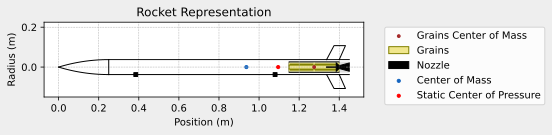

In [19]:
rocket = Rocket(
    radius = rocket_data["radius"],
    mass= rocket_data["mass"],
    power_off_drag="poweroff.csv",
    power_on_drag="poweron.csv",
    inertia= rocket_data["inertia"],
    center_of_mass_without_motor= rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation= rocket_data["coordinate_system_orientation"],
)

print("Rocket object created successfully!")
rocket.add_motor(motor, position=1.40)

nose_cone = rocket.add_nose(
    length=rocket_data["nose_length"], kind=rocket_data["nose_type"], position=rocket_data["nose_position"]
)


aletas = rocket.add_trapezoidal_fins(
    n = rocket_data["n_aletas"],
    root_chord= rocket_data["root_chord"],
    tip_chord= rocket_data["tip_chord"],
    span= rocket_data["span"],
    position= rocket_data["position"],
    cant_angle= rocket_data["cant_angle"],
    sweep_length = rocket_data["sweep_length"]
)

rail_buttons = rocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)


main = rocket.add_parachute(
    name="main",
    cd_s=1.5,
    trigger="apogee",      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)

rocket.draw()

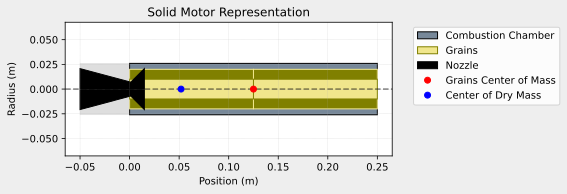

In [26]:
motor.draw()

In [21]:
rocket.info()


Inertia Details

Rocket Mass: 2.482 kg (without motor)
Rocket Dry Mass: 3.209 kg (with unloaded motor)
Rocket Loaded Mass: 3.621 kg
Rocket Structural Mass Ratio: 0.886
Rocket Inertia (with unloaded motor) 11: 0.241 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.241 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.003 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0375 m
Rocket Frontal Area: 0.004418 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.133 m
Rocket Center of Dry Mass - Nozzle Exit: 0.557 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.382 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.043 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 7.127/rad

Center of Pressure

Nose C

In [24]:
flight = Flight(
    rocket=rocket, environment=env, rail_length=4, inclination=85, heading=0, verbose=True
    )

Current Simulation Time: 128.3412 s
>>> Simulation Completed at Time: 122.4885 s


In [25]:
flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 478.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.115 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.314 s
Rail Departure Velocity: 20.568 m/s
Rail Departure Stability Margin: 2.208 c
Rail Departure Angle of Attack: -0.000°
Rail Departure Thrust-Weight Ratio: 8.959
Rail Departure Reynolds Number: 1.018e+05


Burn out State

Burn out time: 1.290 s
Altitude at burn out: 548.885 m (ASL) | 70.885 m (AGL)
Rocket speed at burn out: 128.638 m/s
Freestream velocity 

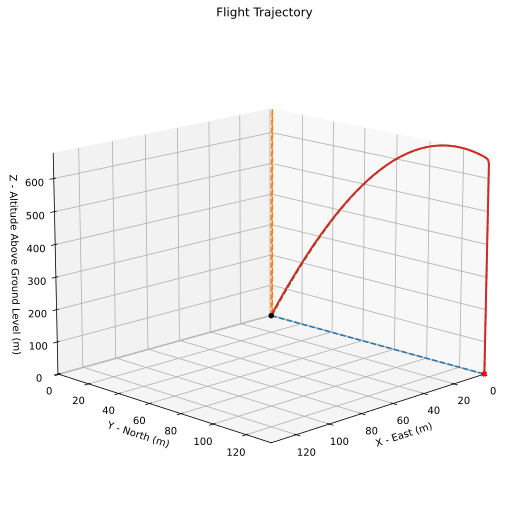

In [31]:
flight.plots.trajectory_3d()

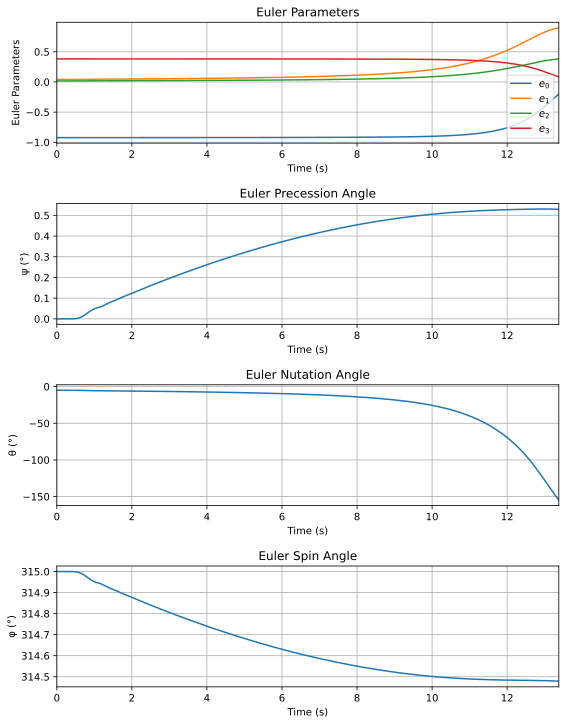

In [30]:
flight.plots.attitude_data()

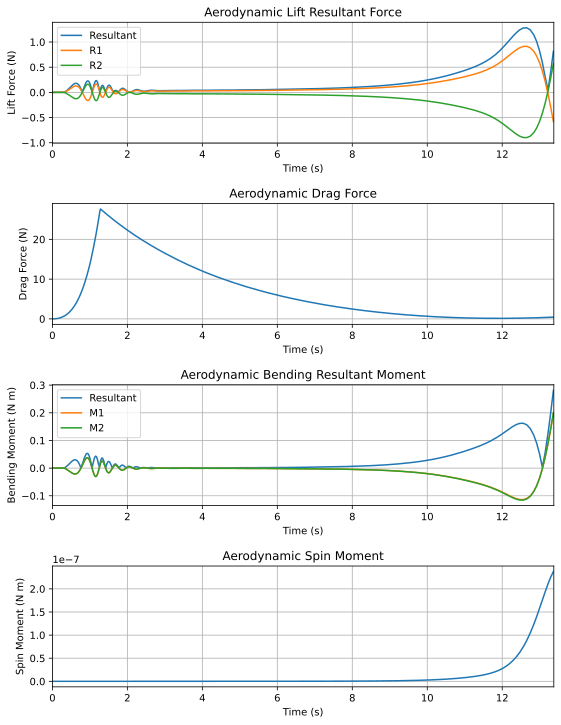

In [29]:
flight.plots.aerodynamic_forces()

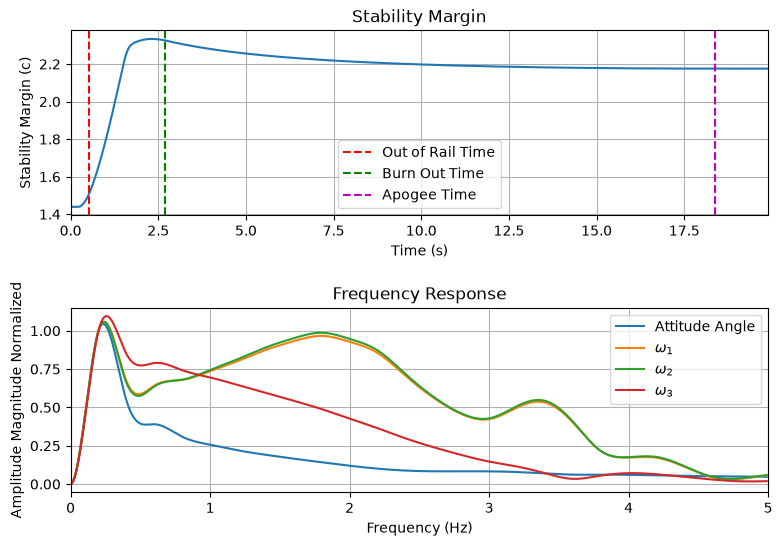

In [16]:
Dedalo_flight.plots.stability_and_control_data()

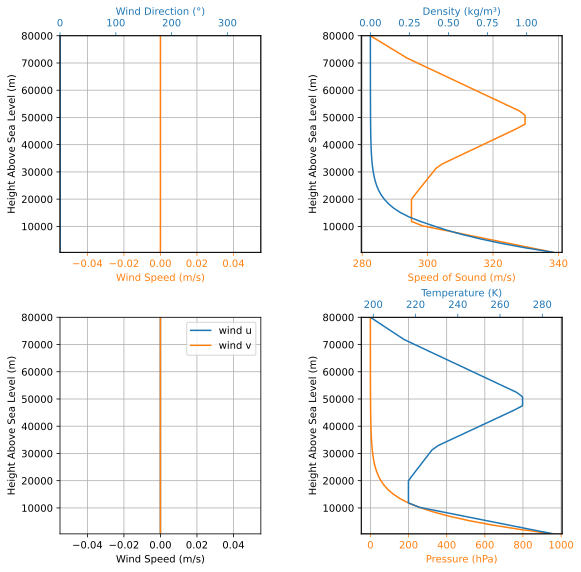

In [32]:
env.plots.atmospheric_model()